In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
from sklearn.datasets import make_blobs
import seaborn as sns


In [37]:
 # make 3-class dataset for classification
 centers = [[-5, 0], [0, 1.5], [5,-1]]
 x, y = make_blobs(n_samples=1000, centers=centers, random_state=42)
 x_new = np.c_[np.ones((len(x), 1)), x[:, 0], x[:, 1], x[:, 0]**2, x[:, 1]**2]

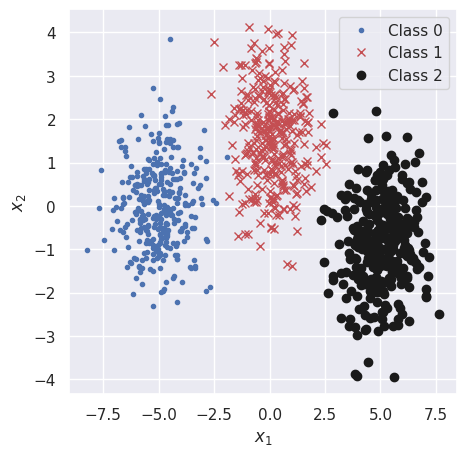

In [38]:
 idx0 = np.argwhere(y == 0)
 idx1 = np.argwhere(y == 1)
 idx2 = np.argwhere(y == 2)
 fig = plt.figure(figsize=(5,5))
 plt.plot(x[idx0,0], x[idx0,1], '.', label="Class 0")
 plt.plot(x[idx1,0], x[idx1,1], "rx", label="Class 1")
 plt.plot(x[idx2,0], x[idx2,1], "ko", label="Class 2")
 plt.xlabel("$x_1$")
 plt.ylabel("$x_2$")
 plt.legend()
 plt.show()

In [39]:
def to_one_hot(y):
    n_classes = y.max() + 1
    m = len(y)
    Y_one_hot = np.zeros((m, n_classes))
    Y_one_hot[np.arange(m), y] = 1
    return Y_one_hot

def softmax(logits):
    exps = np.exp(logits)
    exp_sums = np.sum(exps, axis=1, keepdims=True)
    return exps / exp_sums

def error_function(x, a, y, epsilon=1e-7):
    logits = x.dot(a)
    y_prob = softmax(logits)
    error = -np.mean(np.sum(y * np.log(y_prob + epsilon), axis=1))
    return error

def classifier(x, a):
    logits = x.dot(a)
    y_prob = softmax(logits)
    c = np.zeros((len(y_prob), 1))
    for i in range(0, len(y_prob)):
        c[i, 0] = np.argmax(y_prob[i, :])
    return c

def predict_prob(x, a):
    logits = x.dot(a)
    y_prob = softmax(logits)
    return y_prob


In [53]:
x_train, x_test, y_train, y_test = train_test_split(x_new, y, test_size=0.25, random_state=23)



y_train = to_one_hot(y_train.flatten().astype(int))
y_test = to_one_hot(y_test.flatten().astype(int))



In [54]:
# Batch gradient descent solution.

# learning rate.
alpha = 0.1
# Maximum number of iterations.
n_iterations = 2000

# Random initialization of parameters.
a = np.random.randn(x_train.shape[1],1)

# Create array for storing error values.
Jgd = np.zeros(n_iterations+1)
Jgd_v = np.zeros(n_iterations+1)

# Calculate initial error.
Jgd[0] = error_function(x_train, a, y_train)
Jgd_v[0] = error_function(x_test, a, y_test)

# Batch gradient-descent loop.
minimum_val_error = float("inf")
iteration = 0
error = 1
while iteration < n_iterations:
    gradients = -1/len(y_train)*x_train.T.dot(y_train - softmax(x_train.dot(a)) )
    a = a - alpha * gradients
    Jgd[iteration+1] = error_function(x_train, a, y_train)
    Jgd_v[iteration+1] = error_function(x_test, a, y_test)
    error = np.abs(Jgd[iteration+1] - Jgd[iteration])
    # Store weights for the smallest error ever.
    if(Jgd_v[iteration+1] < minimum_val_error):
        minimum_val_error = Jgd_v[iteration+1]
        a_min = a
    iteration = iteration + 1


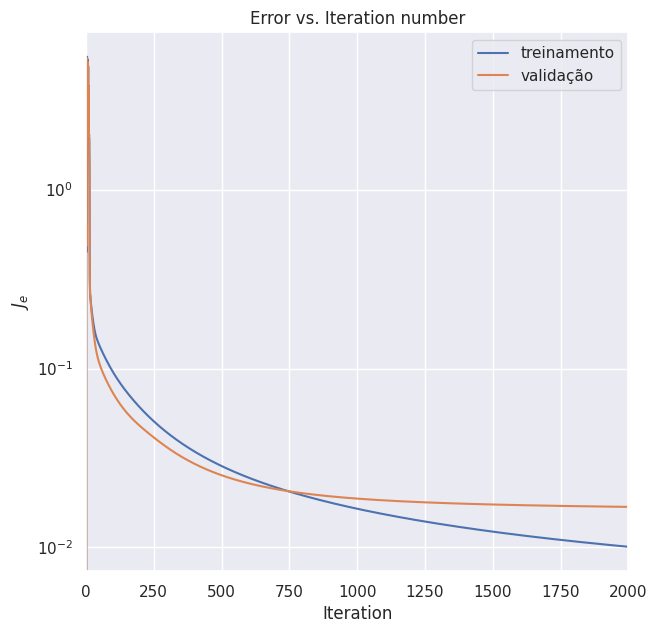

In [55]:
fig = plt.figure(figsize=(7,7))
plt.plot(np.arange(0, iteration), Jgd[0:iteration], label='treinamento')
plt.plot(np.arange(0, iteration), Jgd_v[0:iteration], label='validação')
plt.xlim((0, iteration))
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('$J_e$')
plt.title('Error vs. Iteration number')
plt.legend()
plt.show()

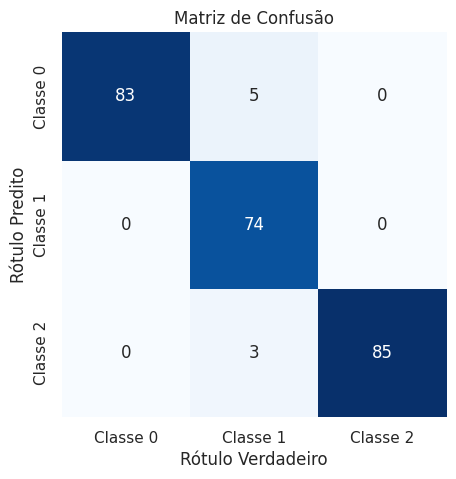

In [56]:
y_test_labels = np.argmax(y_test, axis=1).flatten()
y_pred_labels = y_pred_class.flatten()

# Gerar matriz de confusão
mat = confusion_matrix(y_test_labels, y_pred_labels)

# Plotar
plt.figure(figsize=(5,5))
sns.set()
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['Classe 0','Classe 1','Classe 2'],
            yticklabels=['Classe 0','Classe 1','Classe 2'], cmap="Blues")
plt.xlabel('Rótulo Verdadeiro')
plt.ylabel('Rótulo Predito')
plt.title('Matriz de Confusão')
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


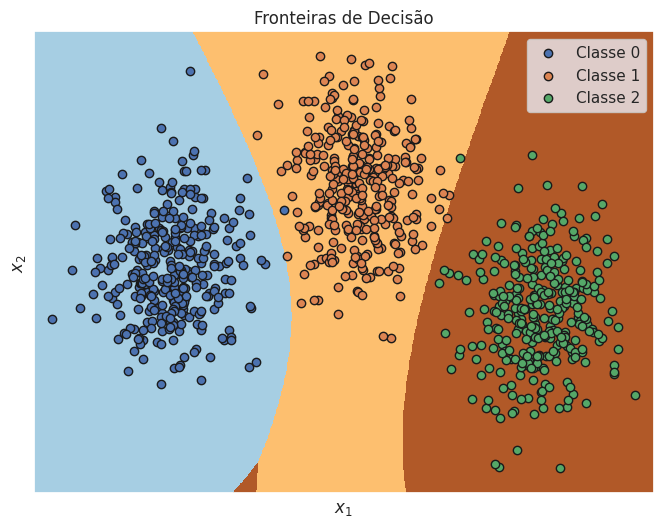

In [57]:
# Definir os limites da malha
x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
h = 0.02  # passo da malha

# Criar a grade (malha)
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Preparar os dados da grade incluindo bias e termos quadráticos
grid = np.c_[np.ones((len(xx.ravel()), 1)),
             xx.ravel(),
             yy.ravel(),
             xx.ravel()**2,
             yy.ravel()**2]

# Fazer a predição no grid
Z = classifier(grid, a_min)
Z = Z.reshape(xx.shape)

# Plotar as fronteiras de decisão
plt.figure(figsize=(8, 6))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, shading='auto')

# Plotar os pontos reais dos dados
plt.scatter(x[idx0, 0], x[idx0, 1], label='Classe 0', edgecolor='k')
plt.scatter(x[idx1, 0], x[idx1, 1], label='Classe 1', edgecolor='k')
plt.scatter(x[idx2, 0], x[idx2, 1], label='Classe 2', edgecolor='k')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Fronteiras de Decisão')
plt.legend()
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

plt.show()


In [50]:
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        83
           1       1.00      0.90      0.95        82
           2       0.97      1.00      0.98        85

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250

